# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [ ]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

In [ ]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


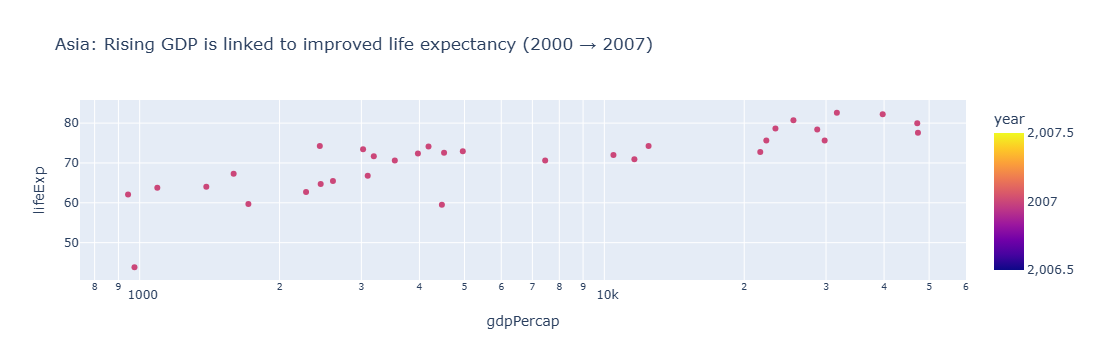

In [7]:
# Task 1 — Scatter plot

import plotly.express as px
df = px.data.gapminder()


# Filter data: Asia + years 2000 and 2007
df_filtered = df[(df['continent'] == 'Asia') & (df['year'].isin([2000, 2007]))]

# Create scatter plot
fig = px.scatter(
    df_filtered,
    x='gdpPercap',
    y='lifeExp',
    color='year',  # only 2 colors
    hover_name='country',
    log_x=True,  # important rule
    title='Asia: Rising GDP is linked to improved life expectancy (2000 → 2007)'
)

fig.show()



## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


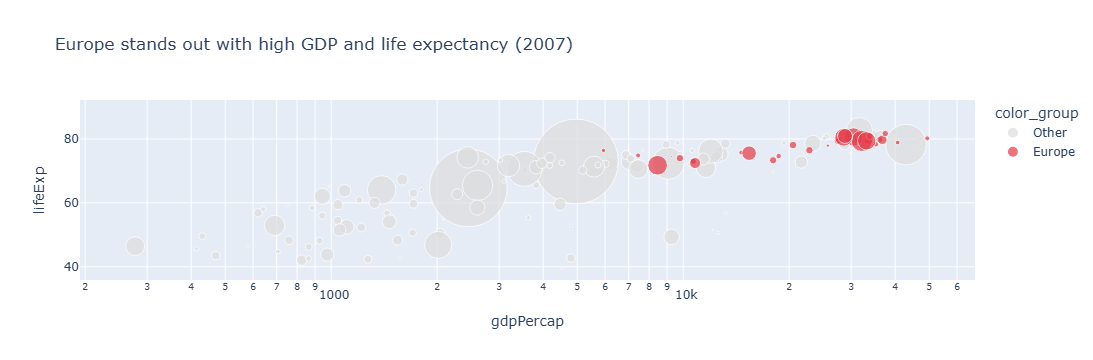

In [8]:
# Task 2 — Bubble chart

import numpy as np

# Filter for year 2007
df_2007 = df[df['year'] == 2007]

# Create a new column for coloring
highlight_continent = 'Europe'

df_2007['color_group'] = np.where(
    df_2007['continent'] == highlight_continent,
    'Europe',
    'Other'
)

# Create bubble chart
fig = px.scatter(
    df_2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    color='color_group',
    hover_name='country',
    log_x=True,
    size_max=60,  # IMPORTANT RULE
    color_discrete_map={
        'Europe': '#E63946',  # highlight
        'Other': '#DDDDDD'    # grey
    },
    title='Europe stands out with high GDP and life expectancy (2007)'
)

# Add annotation (storytelling)
fig.add_annotation(
    x=40000,
    y=80,
    text='European countries cluster at high income & high life expectancy',
    showarrow=True,
    arrowhead=1
)

fig.show()
